# Macro Models

In [16]:
# generate background distribution
from benchmark import MexicanHat, OrnsteinUhlenbeck, SoftLaplace, StudentT

n_dim = 1

# background process
PGenerator = OrnsteinUhlenbeck(n_dim=n_dim, shape_factor_intensity=0.1, temperature=1.0)
PcGenerator = OrnsteinUhlenbeck(n_dim=n_dim, shape_fixed=PGenerator.shape, temperature=2.0)
QGenerator = StudentT(n_dim=n_dim, tail_weight=n_dim/2+2.0, shape_factor_intensity=0.0, beta=20.0)

assert QGenerator.is_normalized(), "QGenerator is not normalized"

In [ ]:
# plot histogram of QGenerator
"""
from matplotlib import pyplot as plt
import torch
plt.figure(figsize=(8, 6))
plt.hist(QGenerator(100000).cpu().numpy(), bins=100, density=True, range=(-10, 10), alpha=0.5, label='QGenerator')
x_grid = torch.linspace(-10, 10, 1000).unsqueeze(1)
plt.plot(x_grid.cpu().numpy(), QGenerator.log_prob(x_grid).exp().cpu().numpy(), label='QGenerator PDF', color='red')
plt.show()
"""
pass

Training:   0%|          | 0/100 [00:00<?, ?it/s]

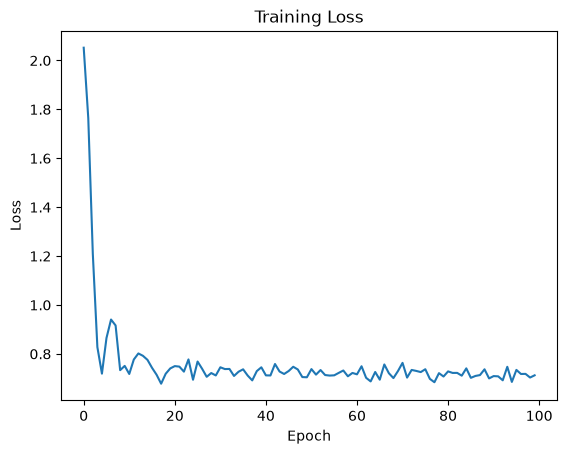

Final loss: 0.7211421728134155


In [17]:
# Definition of the neural network
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import AdamW, Adam
from math import log2
from tqdm.notebook import tqdm

class SimpleNN(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, n_layers: int):
        super(SimpleNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.SiLU(),
            *[nn.Sequential(
                nn.Dropout(0.1), 
                nn.Linear(hidden_dim, hidden_dim),
                nn.SiLU()) for _ in range(n_layers - 1)],
            nn.Linear(hidden_dim, 1)
        )
        # creo il peso b
        self.b = nn.Parameter(torch.tensor(0.0))

    def forward(self, x):
        M = self.net(x)
        p_est = M
        pc_est = M*0.5+self.b
        q_est = QGenerator.log_prob(x).unsqueeze(1)
        logits = torch.cat((p_est, pc_est, q_est), dim=1)
        return logits

myNet = SimpleNN(input_dim=n_dim, hidden_dim=512, n_layers=5)
myNet.train()

optimizer = AdamW(myNet.parameters(), lr=1e-3, weight_decay=1e-5)
criterion = nn.CrossEntropyLoss()

n_epochs = 100
batch_size = 256*int(n_dim*log2(n_dim)+2)
loss_history = []
for epoch in tqdm(range(n_epochs), desc="Training"):
    # genero i batch
    Psamples  = PGenerator (n_samples=batch_size)
    Pcsamples = PcGenerator(n_samples=batch_size)
    Qsamples  = QGenerator (n_samples=batch_size)
    Plabels  = torch.full((batch_size,), 0, dtype=torch.long)
    Pclabels = torch.full((batch_size,), 1, dtype=torch.long)
    Qlabels  = torch.full((batch_size,), 2, dtype=torch.long)
    # merge Psamples e Qsamples
    batch_samples = torch.cat((Psamples, Pcsamples, Qsamples), dim=0)
    batch_labels  = torch.cat((Plabels, Pclabels, Qlabels), dim=0)
    
    optimizer.zero_grad()
    outputs = myNet(batch_samples)
    # outputs has shape (N,3)
    # batch_labels has shape (N,)
    loss = criterion(outputs, batch_labels)
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())

from matplotlib import pyplot as plt
plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

myNet.eval()
with torch.no_grad():
    Psamples = PGenerator(n_samples=10000)
    Pcsamples = PcGenerator(n_samples=10000)
    Qsamples = QGenerator(n_samples=10000)
    Plabels = torch.full((10000,), 0, dtype=torch.long)
    Pclabels = torch.full((10000,), 1, dtype=torch.long)
    Qlabels  = torch.full((10000,), 2, dtype=torch.long)
    batch_samples = torch.cat((Psamples, Pcsamples, Qsamples), dim=0)
    batch_labels = torch.cat((Plabels, Pclabels, Qlabels), dim=0)
    optimizer.zero_grad()
    outputs = myNet(batch_samples)
    loss = criterion(outputs, batch_labels)
    print(f"Final loss: {loss.item()}")

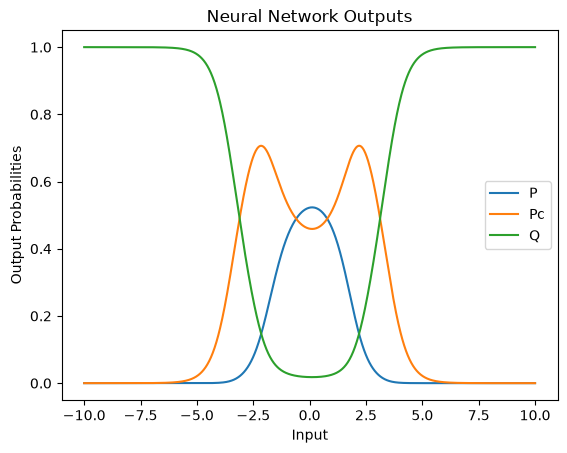

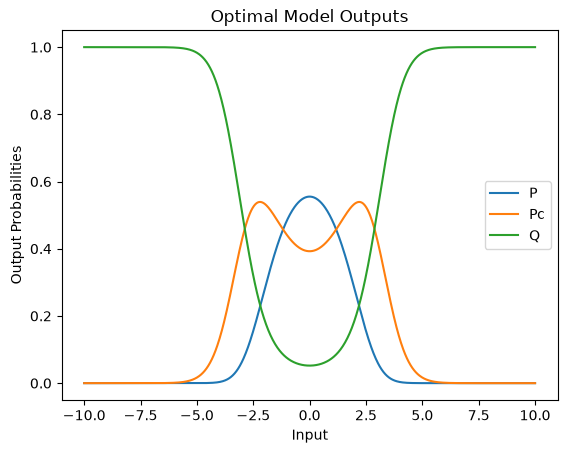

Final loss: 0.7233837246894836
Best loss: 0.693015456199646


In [18]:
# show outputs of the neural network along the axis in 1D

from matplotlib import pyplot as plt

X = torch.linspace(-10, 10, 1000).unsqueeze(1)
with torch.no_grad():
    outputs = torch.softmax(myNet(X), dim=1)
    plt.plot(X.numpy(), outputs.numpy())
    plt.title("Neural Network Outputs")
    plt.xlabel("Input")
    plt.ylabel("Output Probabilities")
    plt.legend(["P", "Pc", "Q"])
    plt.show()
    
# best optimizer: theoretical solution
def best_C(samples):
    p_est = PGenerator.log_prob(samples)
    pc_est = PcGenerator.log_prob(samples)
    q_est = QGenerator.log_prob(samples)
    C = torch.cat((p_est.unsqueeze(1), pc_est.unsqueeze(1), q_est.unsqueeze(1)), dim=1)
    return C

with torch.no_grad():
    outputs = best_C(X).softmax(dim=1)
    plt.plot(X.numpy(), outputs.numpy())
    plt.title("Optimal Model Outputs")
    plt.xlabel("Input")
    plt.ylabel("Output Probabilities")
    plt.legend(["P", "Pc", "Q"])
    plt.show()

pass

myNet.eval()
with torch.no_grad():
    Psamples = PGenerator(n_samples=10000)
    Pcsamples = PcGenerator(n_samples=10000)
    Qsamples = QGenerator(n_samples=10000)
    Plabels = torch.full((10000,), 0, dtype=torch.long)
    Pclabels = torch.full((10000,), 1, dtype=torch.long)
    Qlabels  = torch.full((10000,), 2, dtype=torch.long)
    batch_samples = torch.cat((Psamples, Pcsamples, Qsamples), dim=0)
    batch_labels = torch.cat((Plabels, Pclabels, Qlabels), dim=0)
    optimizer.zero_grad()
    outputs = myNet(batch_samples)
    best_outputs = best_C(batch_samples)
    loss = criterion(outputs, batch_labels)
    best_loss = criterion(best_outputs, batch_labels)
    print(f"Final loss: {loss.item()}")
    print(f"Best loss: {best_loss.item()}")

pass

In [19]:
# get the density p from the trained network
from benchmark import utils

def p_estimated(myNet, samples):
    M = myNet.net(samples).squeeze(1)
    return torch.exp(M)

def p_estimated_from_C(classifier, samples):
    C = classifier(samples).squeeze(1)
    prob_Q = QGenerator.log_prob(samples).exp()
    value1 = C[:,1]**2 / C[:,0]
    value2 = 1 - C[:,2]
    value3 = torch.sqrt(value1 + 4*value2) - torch.sqrt(value1)
    return (value3 ** 2 / (4 * C[:,2])) * prob_Q

# 0. Mass invariant:
gen_integration = OrnsteinUhlenbeck(n_dim=n_dim, temperature=4.0, shape_factor_intensity=0.0)
assert gen_integration.is_normalized, "gen_integration is not normalized"
samples_integration = gen_integration(n_samples=100000)
bg_log_probs = gen_integration.log_prob(samples_integration)
# remove couples of samples with bg_log_probs.exp() < 1e-10 to avoid numerical issues
mask = bg_log_probs.exp() >= 1e-10
samples_integration = samples_integration[mask]
bg_log_probs = bg_log_probs[mask]
empirical_mass = torch.mean(p_estimated(myNet, samples_integration) / bg_log_probs.exp()).item()
print(f"Empirical mass: {empirical_mass}")

def p_corrected(myNet, samples):
    return p_estimated(myNet, samples) / empirical_mass

gen_integration = OrnsteinUhlenbeck(n_dim=n_dim, temperature=4.0, shape_factor_intensity=0.0)
assert gen_integration.is_normalized, "gen_integration is not normalized"
samples_integration = gen_integration(n_samples=100000)
bg_log_probs = gen_integration.log_prob(samples_integration)
Z = utils.compute_normalization_constant(PGenerator, samples_integration, bg_log_probs)
print(f"Normalization constant of objective density: {Z}")

def p_true(Pgenerator, samples):
    if Pgenerator.is_normalized:
        return Pgenerator.log_prob(samples).exp()
    else:
        return Pgenerator.log_prob(samples).exp() / Z

Empirical mass: 2.4588189125061035
Normalization constant of objective density: 1.0


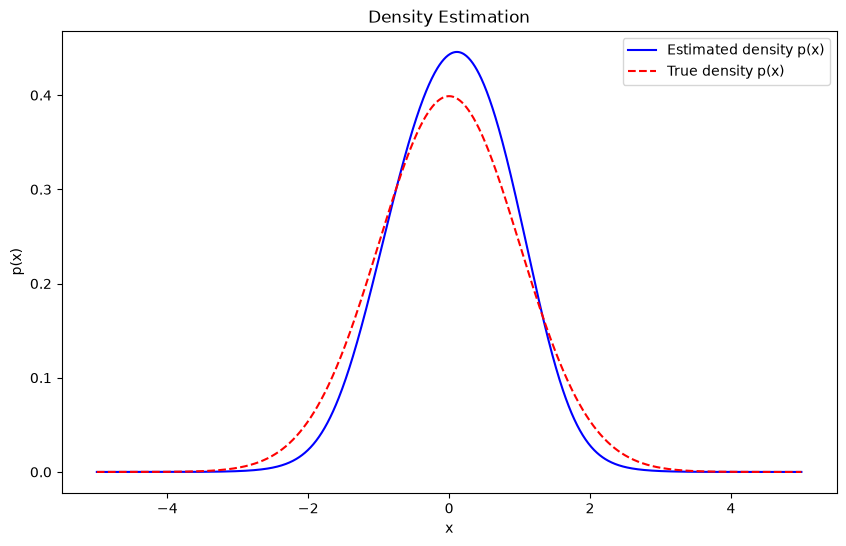

In [20]:
# plot

X = torch.linspace(-5, 5, 1000).unsqueeze(1)
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(X.numpy(), p_corrected(myNet, X).detach().cpu().numpy(), label='Estimated density p(x)', color='blue')
plt.plot(X.numpy(), p_true(PGenerator, X).detach().cpu().numpy(), label='True density p(x)', color='red', linestyle='dashed')
plt.xlabel('x')
plt.ylabel('p(x)')
plt.title('Density Estimation')
plt.legend()
plt.show()

pass

In [7]:
# calcolo dell'errore

# 1. KL(p_true | p_corrected) = E[log(p_true / p_corrected)] = E[log(p_true)] - E[log(p_corrected)]
def KL_divergence(PGenerator, QGenerator_log_prob):
    Psamples = PGenerator(n_samples=100000)
    Z = utils.compute_normalization_constant(PGenerator, Psamples, PGenerator.log_prob(Psamples))
    entropy = torch.mean(PGenerator.log_prob(Psamples)) - torch.log(torch.tensor(Z.item()))
    KL_divergence = entropy - torch.mean(QGenerator_log_prob(Psamples))
    return KL_divergence
log_p_corrected = lambda x: torch.log(p_corrected(myNet, x) + 1e-12) # 1e-12 per evitare log(0)
print(f"KL divergence: {KL_divergence(PGenerator, log_p_corrected).item()}")

# 2. JS(p_true | p_corrected) = 0.5 * KL(p_true | m) + 0.5 * KL(p_corrected | m), where m = 0.5 * (p_true + p_corrected)
m_log_prob = lambda x: torch.log(0.5 * (p_true(PGenerator, x) + p_corrected(myNet, x)))
kl1 = KL_divergence(PGenerator, m_log_prob)
Qsamples = QGenerator(n_samples=100000)
q_densities = QGenerator.log_prob(Qsamples).exp()
p_theta_densities = p_corrected(myNet, Qsamples)
m_densities = 0.5 * (p_true(PGenerator, Qsamples) + p_theta_densities)
# filtro i dati con m_densities < 1e-10 per evitare log(0)
p_theta_densities = p_theta_densities[m_densities >= 1e-10]
q_densities = q_densities[m_densities >= 1e-10]
m_densities = m_densities[m_densities >= 1e-10]
kl2 = torch.mean(p_theta_densities / q_densities * torch.log(p_theta_densities / m_densities))
print(f"JS divergence: {0.5 * kl1.item() + 0.5 * kl2.item()}")

# 3. L1, L2, L_infty norms of the difference between p_true and p_corrected
Qsamples = QGenerator(n_samples=100000)
densities = QGenerator.log_prob(Qsamples).exp()
err = p_true(PGenerator, Qsamples) - p_corrected(myNet, Qsamples)
print(f"L1 norm: {torch.mean(torch.abs(err) / densities).item()}")
print(f"L2 norm: {torch.sqrt(torch.mean(err**2 / densities)).item()}")

print(f"L_infty norm: {torch.max(torch.abs(err)).item()}")

# 4. Fisher Divergence: E[||grad(log(p_true)) - grad(log(p_corrected))||^2]
Psamples = PGenerator(n_samples=100000)
Psamples.requires_grad_(True) # Abilitiamo i gradienti per l'input!
Pscore = PGenerator.score(Psamples)
# Estraiamo l'output M della rete (log-prob non normalizzata)
# Visto che p(x) \propto exp(M(x)), lo score è semplicemente grad(M(x))
M_out = myNet.net(Psamples) 
# Calcoliamo la derivata spaziale esatta tramite autograd
Net_score = torch.autograd.grad(
    outputs=M_out, 
    inputs=Psamples, 
    grad_outputs=torch.ones_like(M_out), 
    create_graph=False
)[0]
fisher_div = torch.mean(torch.sum((Pscore - Net_score)**2, dim=-1))
print(f"Fisher Divergence: {fisher_div.item()}")

AttributeError: 'float' object has no attribute 'item'